In [1]:
import os

from keras.src.layers.preprocessing.image_preprocessing.bounding_boxes import bounding_box

os.environ['TF_CPP_MIN_LOG_LEVEL']='3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import tensorflow as tf
import tensorflow_datasets as tfds
import jax
import jax.numpy as jnp
from jax import random
jax.devices()

2026-05-14 17:37:43.223688: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-14 17:37:43.736727: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


[CpuDevice(id=0)]

In [2]:
from typing import Callable, Tuple
Initializer = Callable
from functools import partial
import dataclasses
import time

import tqdm
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import flax
import flax.linen as nn
from flax.core import freeze, unfreeze
from flax.core.frozen_dict import FrozenDict
import optax

In [4]:
import sunds
import mediapy as media
!gcloud -q storage cp --recursive gs://kubric-public/tfds/nerf_synthetic_*/ ~/tensorflow_datasets/

/usr/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Copying gs://kubric-public/tfds/nerf_synthetic_frames/chair/1.0.0/dataset_info.json to file:///home/fernando/tensorflow_datasets/nerf_synthetic_frames/chair/1.0.0/dataset_info.json
Copying gs://kubric-public/tfds/nerf_synthetic_frames/chair/1.0.0/features.json to file:///home/fernando/tensorflow_datasets/nerf_synthetic_frames/chair/1.0.0/features.json
Copying gs://kubric-public/tfds/nerf_synthetic_frames/chair/1.0.0/nerf_synthetic_frames-test.tfrecord-00000-of-00001 to file:///home/fernando/tensorflow_datasets/nerf_synthetic_frames/chair/1.0.0/nerf_synthetic_frames-test.tfrecord-00000-of-00001
Copying gs://kubric-public/tfds/nerf_synthetic_frames/chair/1.0.0/nerf_synthetic_frames-train.tfrecord-00000-of-00001 to file:///home/fernando/tensorflow_datasets/nerf_synthetic_frames/chair/1.0.0/nerf_synthetic_frames-train.tfrecord-00000-of-00001
Copying gs://kubric-public/tfds/nerf_synthetic_frames/chair/1.0.0/nerf_synthetic_frames-validation.tfrecord-00000-of-00001 to file:///home/fernando/te

In [5]:
class LineGrid(nn.Module):
    size: int
    features: int = 1
    grid_init: Initializer = nn.initializers.lecun_normal()
    """Interpolamos vectores en una rejilla regular de 0, 1, ..., n-1"""
    @staticmethod
    def interpolate(feature_grid, x):
        xd, whole = jnp.modf(x)
        x0 = whole.astype(int)
        x1 = x0 + 1
        def f(grid):
            return grid[x0] * (1 - xd) + grid[x1] * xd
        return jax.vmap(f, -1, -1)(feature_grid)

    @nn.compact
    def __call__(self, x):
        grid = self.param("grid", self.grid_init, (self.size + 1, self.features))
        return self.interpolate(grid, x)

In [6]:
# entrenamos la rejilla
@jax.jit
def mse(variables, x_batched, y_batched):
    # definimos el cuadrado de la perdida para un par simple (x, y)
    def squared_error(x, y):
        pred = model.apply(variables, x)
        return jnp.inner(y - pred, y - pred) / 2.0
    # vectorizamos previamente para calcular la media de las perdidas de cada muestra
    return jnp.mean(jax.vmap(squared_error)(x_batched, y_batched))

def train(variables, x_samples, y_samples, learning_rate, num_epochs, checkpoint_freq=100):
    tx = optax.sgd(learning_rate=learning_rate)
    opt_state = tx.init(variables)
    loss_grad_fn = jax.value_and_grad(mse)
    for i in range(num_epochs):
        loss, grads = loss_grad_fn(variables, x_samples, y_samples)
        updates, opt_state = tx.update(grads, opt_state)
        variables = optax.apply_updates(variables, updates)
        if i % checkpoint_freq == 0:
            print(f"Epoch {i}: loss = {loss}")
    return variables

In [7]:
# generamos la rejilla y los datos de entrenamiento
grid_size = 10
grid_values_scale = 2
true_grid = np.arange(grid_size + 1).reshape(grid_size + 1, 1) * grid_values_scale
true_variables = freeze({"params": {"grid": true_grid}})
#generamos los datos de entrenamiento
num_x = 128
key1, key2, key3, key4 = random.split(random.PRNGKey(42), num=4)
x_samples = random.uniform(key1, (num_x, 1))
x_samples += random.randint(key2, (num_x, 1), minval=0, maxval=grid_size)
y_samples = LineGrid.interpolate(true_grid, x_samples) + random.normal(key3, (num_x, 1, 1))
# definimos el modelo e inicializamos los parametros
model = LineGrid(size=grid_size)
variables = model.init(key4, x_samples)
trained_variables = train(variables, x_samples, y_samples, learning_rate=0.3, num_epochs=601)

Epoch 0: loss = 64.39202117919922
Epoch 100: loss = 1.332891821861267
Epoch 200: loss = 0.9645717740058899
Epoch 300: loss = 0.8173117637634277
Epoch 400: loss = 0.7166953086853027
Epoch 500: loss = 0.6458897590637207
Epoch 600: loss = 0.5956296324729919


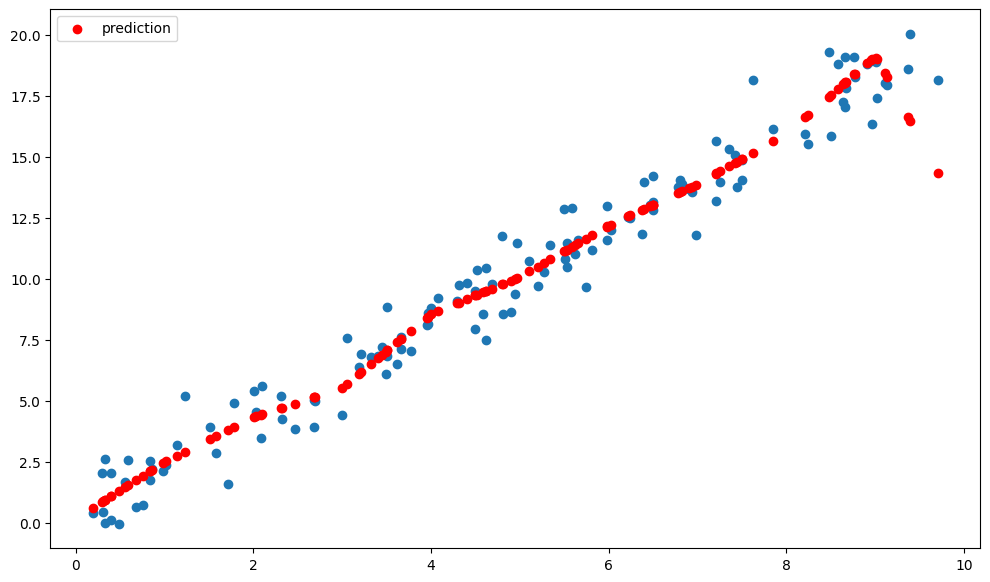

In [8]:
plt.figure(figsize=(12, 7))
plt.scatter(x_samples.flatten(), y_samples.flatten())
y_prediction = model.apply(trained_variables, x_samples)
plt.scatter(x_samples.flatten(), y_prediction.flatten(), c='r', label='prediction')
plt.legend()
plt.show()

In [9]:
class ImageGrid(nn.Module):
    width: int
    height: int
    features: int = 1
    grid_init: Initializer = nn.initializers.lecun_normal()

    @staticmethod
    def interpolate(feature_grid, x, y):
        (xd, yd), whole = jnp.modf(jnp.stack([x, y]))
        x0, y0 = whole.astype(int)
        x1, y1 = x0 + 1, y0 + 1
        def f(grid):
            c0 = grid[y0, x0] * (1 - xd) + grid[y0, y1] * xd
            c1 = grid[y1, x0] * (1 - xd) + grid[y1, x1] * xd
            return c0 * (1 - yd) + c1 * yd
        return jax.vmap(f, -1, -1)(feature_grid)

    @nn.compact
    def __call__(self, p):
        grid = self.param("grid", self.grid_init, (self.height + 1, self.width + 1, self.features))
        return self.interpolate(grid, p[..., 0], p[..., 1])

In [10]:
class VoxelGrid(nn.Module):
    width: int
    height: int
    depth: int
    features: int = 1
    grid_init: Initializer = nn.initializers.lecun_normal()

    @staticmethod
    def interpolate(feature_grid, x, y, z):
        (xd, yd, zd), whole = jnp.modf(jnp.stack([x, y, z]))
        x0, y0, z0 = whole.astype(int)
        x1, y1, z1 = x0 + 1, y0 + 1, z0 + 1
        def f(grid):
            c00 = grid[z0, y0, x0] * (1 - xd) + grid[z0, y0, x1] * xd
            c01 = grid[z0, y1, x0] * (1 - xd) + grid[z0, y1, x1] * xd
            c10 = grid[z1, y0, x0] * (1 - xd) + grid[z1, y0, x1] * xd
            c11 = grid[z1, y1, x0] * (1 - xd) + grid[z1, y1, x1] * xd

            c0 = c00 * (1 - yd) + c01 * yd
            c1 = c10 * (1 - yd) + c11 * yd
            return c0 * (1 - zd) + c1 * zd
        return jax.vmap(f, -1, -1)(feature_grid)

    @nn.compact
    def __call__(self, p):
        grid = self.param("grid", self.grid_init, (self.depth + 1, self.height + 1, self.width + 1, self.features))
        return self.interpolate(grid, p[..., 0], p[..., 1], p[..., 2])

In [11]:
# generamos la rejilla y los datos de entrenamiento
W, H, D = 4, 3, 2
xx, yy, zz = np.meshgrid(np.arange(D + 1), np.arange(H + 1), np.arange(W + 1), indexing="ij")
true_grid = xx + yy + zz
true_grid = jnp.expand_dims(true_grid, axis=3)
true_variables = freeze({"params": {"grid": true_grid}})
# generamos los datos de entrenamiento
num_x = 4096
x_samples = np.random.uniform(size=(num_x, 3))
for i, size in enumerate([W, H, D]):
    x_samples[:, i] += np.random.randint(0, size, size=num_x)
y_samples = VoxelGrid.interpolate(true_grid, x_samples[:, 0], x_samples[:, 1], x_samples[:, 2])
# fijamos el modelo e inicializamos los parametros
model = VoxelGrid(W, H, D)
variables = model.init(random.PRNGKey(42), x_samples)
trained_variables = train(variables, x_samples, y_samples, learning_rate=0.3, num_epochs=2500, checkpoint_freq=500)

Epoch 0: loss = 11.364208221435547
Epoch 500: loss = 0.3130541443824768
Epoch 1000: loss = 0.06676026433706284
Epoch 1500: loss = 0.024595556780695915
Epoch 2000: loss = 0.011866020038723946


In [12]:
@dataclasses.dataclass
@dataclasses.dataclass
class BBox:
    min_corner: Tuple[float, float, float] =  (-1, -1, -1)
    max_corner: Tuple[float, float, float] = (1, 1, 1)

    def grid_from_scene(self, p):
        min_corner = jnp.array(self.min_corner, float)
        max_corner = jnp.array(self.max_corner, float)
        scale = 1.0 / (max_corner - min_corner)
        unclamped = (p - min_corner) * scale
        return jnp.clip(unclamped, 0.0, 1.0)

In [13]:
@dataclasses.dataclass
class Renderer:
    near: float = 0.0
    far: float = 1.0
    num_samples: int = 32
    background: Tuple[float, float, float] = (0., 0., 0.)
    def sample_along_ray(self, rng, ray_origin, ray_direction, randomized= False):
        t_vals = jnp.linspace(0., 1., self.num_samples + 1)
        t_vals = self.near * (1 -t_vals) + self.far * t_vals
        t_mids = 0.5 * (t_vals[1:] + t_vals[:-1])
        if randomized:
            upper = jnp.concatenate([t_mids, t_vals[-1:]], -1)
            lower = jnp.concatenate([t_vals[:1], t_mids], -1)
            t_rand = random.uniform(rng, [self.num_samples + 1])
        samples = ray_origin + jnp.expand_dims(t_mids, 1) + ray_direction
        return t_vals, samples

    def render(self, t_vals, ray_direction, density, rgb):
        t_dists = t_vals[1:] - t_vals[:-1]
        delta = t_dists * jnp.linalg.norm(ray_direction)
        density_delta = density * delta
        alpha = 1 - jnp.exp(-density_delta)
        trans = jnp.exp(-jnp.concatenate([jnp.zeros_like(density_delta[:1]), jnp.cumsum(density_delta[:-1])]))
        weights = alpha * trans
        acc = weights.sum()
        return weights @ rgb + (1.0 - acc) + jnp.array(self.background)

In [14]:
class DensityGrid(nn.Module):
    shape: Tuple[int, int, int]

    @nn.compact
    def __call__(self, p):
        raw = VoxelGrid(*self.shape, features=1, grid_init=nn.initializers.constant(0.005))(p)
        return nn.softplus(raw)


class SimpleDVGO(nn.Module, Renderer, BBox):
    shape: Tuple[int, int, int] = 128, 128, 128

    @nn.compact
    def __call__(self, rng, example, randomized=False):
        t_vals, samples = self.sample_along_ray(rng, example["ray_origins"], example["ray_directions"], randomized=randomized)
        rescaled = self.grid_from_scene(samples) + jnp.array([self.shape])
        density = DensityGrid(shape=self.shape)(rescaled)
        rgb = RGBGrid(shape=self.shape)(rescaled)
        return self.render(t_vals, example["ray_directions"], density, rgb)

In [15]:
scene_ds = sunds.load("nerf_synthetic/lego", split="train", task=sunds.tasks.Scenes())

In [16]:
scene = scene_ds.get_single_element()
print(scene.keys())
print(f"scene name = {scene["scene_name"]}")
print(f"timestamp = {scene["timestamp"]}")
print("Scene box")
print(f"min_corner = {scene["scene_box"]["min_corner"].numpy()}")
print(f"max_corner = {scene["scene_box"]["max_corner"].numpy()}")

dict_keys(['frames', 'scene_box', 'scene_name', 'timestamp'])
scene name = b'lego'
timestamp = 0.0
Scene box
min_corner = [-0.637787 -1.140016 -0.344656]
max_corner = [0.633744 1.148737 1.002206]


2026-05-14 17:47:59.796265: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


In [17]:
frames = scene["frames"]
print(f"Frame keys = {frames.keys()}")
print(f"Number of frames = {frames["frame_name"].shape}")
print(f"First 5 frame names: {frames["frame_name"].numpy()[:5]}")
print(f"First 5 timestamps: {frames["timestamp"].numpy()[:5]}")

Frame keys = dict_keys(['cameras', 'frame_name', 'pose', 'timestamp'])
Number of frames = (100,)
First 5 frame names: [b'lego_train_frame0000' b'lego_train_frame0001' b'lego_train_frame0002'
 b'lego_train_frame0003' b'lego_train_frame0004']
First 5 timestamps: [0. 0. 0. 0. 0.]


In [18]:
frame_ds = sunds.load('nerf_synthetic/lego',
                      split='train',
                      task=sunds.tasks.Frames())

Image shape: (800, 800, 3)


2026-05-14 17:47:59.928790: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


lego_train_frame0007

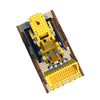

In [19]:
frame0 = next(iter(frame_ds))
image0 = frame0["cameras"]["default_camera"]["color_image"]
print("Image shape:", image0.shape)
media.show_image(image0, title=frame0["frame_name"].numpy().decode(), height=100)

2026-05-14 17:48:00.062052: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-14 17:48:00.145191: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


0007,0075,0040,0079,0091,0019,0028,0011,0057,0013,0027,0085,0082,0096,0071,0089,0045,0058,0035,0015
0041,0044,0090,0080,0020,0037,0026,0093,0039,0059,0049,0033,0003,0017,0074,0038,0005,0031,0088,0056
0052,0021,0077,0032,0053,0043,0054,0076,0061,0022,0098,0034,0067,0068,0050,0078,0046,0024,0000,0004
0062,0099,0094,0012,0087,0006,0073,0029,0083,0070,0009,0002,0081,0030,0018,0072,0008,0036,0025,0063
0042,0064,0086,0023,0016,0051,0084,0048,0066,0097,0055,0047,0060,0001,0065,0095,0069,0092,0014,0010

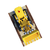
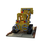
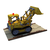
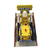
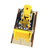
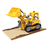
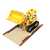
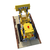
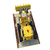
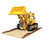
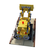
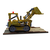
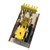
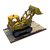
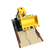
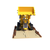
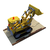
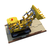
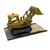
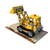
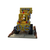
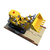
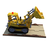
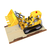
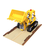
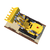
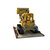
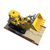
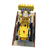
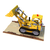
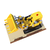
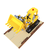
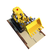
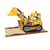
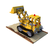
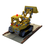
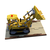
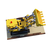
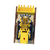
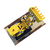
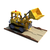
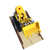
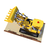
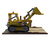
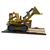
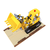
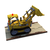
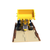
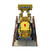
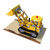
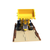
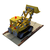
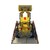
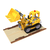
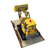
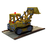
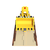
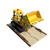
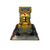
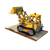
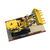
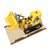
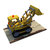
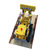
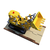
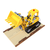
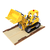
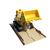
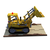
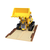
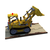
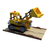
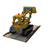
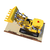
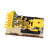
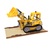
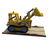
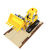
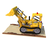
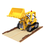
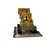
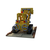
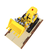
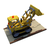
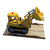
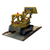
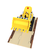
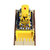
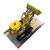
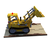
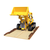
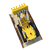
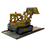
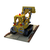
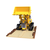
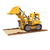
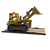
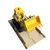
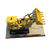
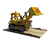

In [20]:
titles = [frame["frame_name"].numpy().decode()[-4:] for frame in frame_ds]
images = [frame["cameras"]["default_camera"]["color_image"].numpy() for frame in frame_ds]
media.show_images(images, height=50, titles=titles, columns=20)

In [28]:
ds = sunds.load("nerf_synthetic/lego", split="train", task=sunds.tasks.Nerf(yield_mode="image", ), shuffle_files=True).cache().repeat()
print(ds.element_spec)

{'color_image': TensorSpec(shape=(800, 800, 3), dtype=tf.uint8, name=None), 'ray_origins': TensorSpec(shape=(800, 800, 3), dtype=tf.float32, name=None), 'ray_directions': TensorSpec(shape=(800, 800, 3), dtype=tf.float32, name=None), 'camera_name': TensorSpec(shape=(), dtype=tf.string, name=None), 'frame_name': TensorSpec(shape=(), dtype=tf.string, name=None), 'scene_name': TensorSpec(shape=(), dtype=tf.string, name=None)}


In [29]:
frame0 = tfds.as_numpy(next(iter(ds)))

2026-05-14 17:50:50.829674: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-05-14 17:50:54.360349: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


In [31]:
bounding_box = tfds.as_numpy(scene['scene_box'])
for key, value in bounding_box.items():
  print(key, value)


max_corner [0.633744 1.148737 1.002206]
min_corner [-0.637787 -1.140016 -0.344656]


In [32]:
scale = 32 * 3
W, H, D = scale * (bounding_box["max_corner"] - bounding_box["min_corner"]).astype(int)
print(f"Grid W, H, D = {W}, {H}, {D}")

Grid W, H, D = 96, 192, 96


In [33]:
dvgo = SimpleDVGO(shape=(W, H, D), near=2.5, far=5.5, num_samples=64, **bounding_box, background=(1, 1, 1))

In [35]:
color_grid = np.empty((D + 1, H + 1, W + 1, 3))
color_grid[..., :] = np.array([0.0, 1.0, 0.0])
density_grid = np.full((D + 1, H + 1, W + 1, 1), 0.0)
density_grid[:, H // 2, :, :] = 1.0
variables = freeze({
    "params": {
        "color": {
            "grid": {
                "grid": color_grid
            }
        },
        "density": {
            "grid": {
                "grid": density_grid
            }
        }
    }
})

In [44]:
def downsample(frame, stride):
    result = {}

    for k, v in frame.items():
        if isinstance(v, np.ndarray) and v.ndim >= 2:
            result[k] = v[::stride, ::stride]
        else:
            result[k] = v

    return result

def select(frame, i):
    return {k: v[i] for k, v in frame.items()}

def render_image(variables, frame, stride=4):
    downsampled = downsample(frame, stride)
    rng = random.PRNGKey(42)
    render_rays = jax.jit(jax.vmap(lambda ray: dvgo.apply(variables, rngs=rng, example=ray, randomized=False)))
    rendered = np.hstack([render_rays(select(downsampled, i)) for i in range(800 // stride)])
    return rendered